
# Demo del framework de ejecución en video (tracking de jugadores)

Componente adicional (no forma parte de la rúbrica de la Actividad 3). Corre `run_inference_video.py`
—que usa el detector YOLO-pose entrenado en `actividad_3b_yolo_pose_deteccion.ipynb`— sobre un video, frame por
frame, trackeando a cada jugador con una **identidad persistente** (ByteTrack, vía `model.track()` de
ultralytics) en vez de detectarlo de forma independiente en cada frame, y dibuja sus 5 keypoints.

**Nota sobre el video de entrada**: este repositorio solo trae los *frames ya extraídos* (imágenes
sueltas) del material original, no los archivos `.mp4` crudos. Para poder demostrar el framework
"sobre un video" se reconstruye un clip corto a partir de los frames de un mismo rally (`Punto_1-4_mp4`,
28 frames, todos dentro del split de train), ordenados por número de frame. En uso real, el framework
recibiría directamente el archivo de video original de la cámara.


## Checkpoint 1 — Reconstruir un video corto de demo a partir de un rally

In [1]:

import sys
from pathlib import Path

import cv2
import pandas as pd

def find_repo_root(start=None):
    p = Path(start or Path.cwd())
    for _ in range(5):
        if (p / "data.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No se encontró data.yaml")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data" / "Padel_an_2-6"
sys.path.insert(0, str(ROOT))

splits = pd.read_csv(ROOT / "data" / "processed" / "image_splits.csv")
rally = "Punto_1-4_mp4"
rally_imgs = splits[splits.rally_id == rally].copy()
rally_imgs["frame_no"] = rally_imgs["image_id"].str.extract(r"-(\d+)_jpg").astype(int)
rally_imgs = rally_imgs.sort_values("frame_no")

# Las imágenes viven en data/Padel_an_2-6/{train,valid,test} tal como están (sin copiar ni
# reorganizar nada); buscamos cada frame del rally en las tres carpetas.
frame_paths = []
for iid in rally_imgs.image_id:
    for orig_split in ["train", "valid", "test"]:
        candidate = DATA_DIR / orig_split / "images" / f"{iid}.jpg"
        if candidate.exists():
            frame_paths.append(candidate)
            break
print(f"Frames encontrados para {rally}: {len(frame_paths)}")

demo_dir = ROOT / "data" / "processed" / "video_demo"
demo_dir.mkdir(parents=True, exist_ok=True)
demo_video_path = demo_dir / f"{rally}_demo.mp4"

first = cv2.imread(str(frame_paths[0]))
h, w = first.shape[:2]
writer = cv2.VideoWriter(str(demo_video_path), cv2.VideoWriter_fourcc(*"mp4v"), 6.0, (w, h))
for p in frame_paths:
    writer.write(cv2.imread(str(p)))
writer.release()
print("Video de demo reconstruido en:", demo_video_path)


Frames encontrados para Punto_1-4_mp4: 28


Video de demo reconstruido en: C:\Users\luisj\OneDrive\Documentos\Maestria Inteligencia Artificial\Tercer Semestre\Primer Ciclo\Tecnicas_Avanzadas_Modelado_En_IA\Unidad_2\padel-impact-position-detection\data\processed\video_demo\Punto_1-4_mp4_demo.mp4


## Checkpoint 2 — Correr el framework de ejecución (tracking) sobre el video de demo

In [2]:

from run_inference_video import process_video

output_path = demo_dir / f"{rally}_anotado.mp4"
seen_ids = process_video(demo_video_path, output_path, progress_every=10)


frame 10/28  jugadores vistos hasta ahora: 5
frame 20/28  jugadores vistos hasta ahora: 8


Video anotado escrito en: C:\Users\luisj\OneDrive\Documentos\Maestria Inteligencia Artificial\Tercer Semestre\Primer Ciclo\Tecnicas_Avanzadas_Modelado_En_IA\Unidad_2\padel-impact-position-detection\data\processed\video_demo\Punto_1-4_mp4_anotado.mp4
Jugadores distintos trackeados en el clip: 10 (IDs: [1, 2, 3, 4, 8, 10, 12, 13, 15, 16])


## Checkpoint 3 — Ver algunos frames anotados

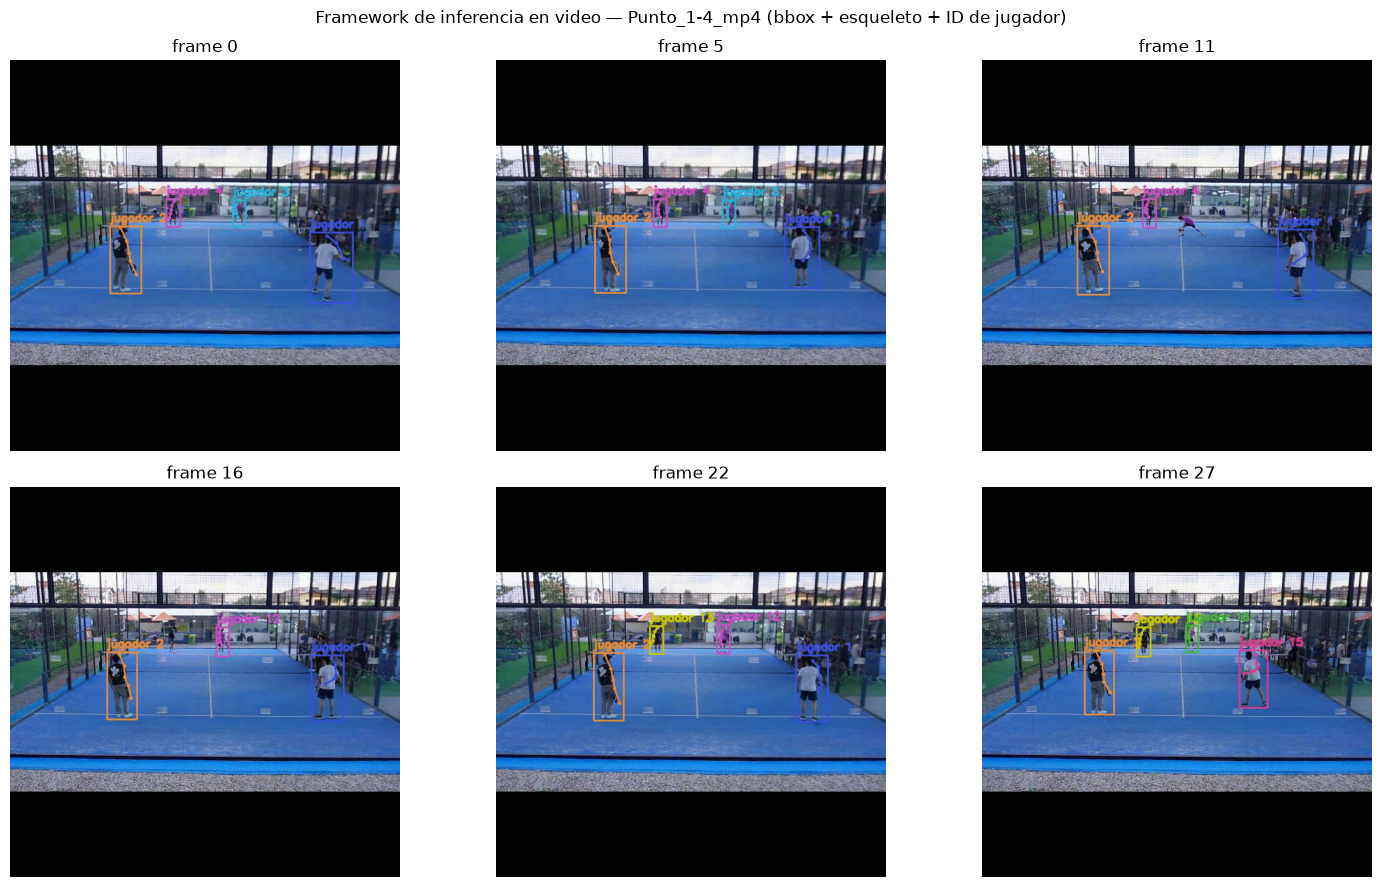

Jugadores distintos trackeados en el clip: 10 (IDs: [1, 2, 3, 4, 8, 10, 12, 13, 15, 16])


In [3]:

import matplotlib.pyplot as plt

cap = cv2.VideoCapture(str(output_path))
n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
sample_idxs = sorted(set(int(x) for x in
                          [0, n_total * 0.2, n_total * 0.4, n_total * 0.6, n_total * 0.8, n_total - 1]))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, idx in zip(axes.flat, sample_idxs):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    if ok:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"frame {idx}")
    ax.axis("off")
cap.release()
plt.suptitle(f"Framework de inferencia en video — {rally} (bbox + esqueleto + ID de jugador)")
plt.tight_layout()
plt.show()

print(f"Jugadores distintos trackeados en el clip: {len(seen_ids)} (IDs: {sorted(seen_ids)})")



## Checkpoint 4 — Observaciones

- El detector se entrenó sobre un dataset chico (335 imágenes); puede fallar en frames con oclusión,
  jugadores lejanos o movimiento rápido — es una prueba de concepto del framework, no un modelo listo
  para producción.
- El video de demo se reconstruyó a partir de frames ya extraídos (no consecutivos al 100%, según el
  muestreo original de Roboflow), por lo que el movimiento se ve "a saltos" y el tracker puede perder o
  reasignar IDs con más frecuencia que en un video fluido real (ByteTrack se apoya en la continuidad
  entre frames consecutivos para asociar detecciones).
- Cada jugador mantiene su color y su ID mientras el tracker lo siga; si se pierde momentáneamente
  (oclusión, salida de cuadro) puede reaparecer con un ID nuevo — es una limitación conocida de
  ByteTrack sin re-identificación visual, no un bug del framework.
